# Energy Consumption Prediction and Household Segmentation in Zurich

This notebook analyzes monthly household electricity consumption using the HEAPO dataset.


## Problem Definition

The main objective is to **predict monthly electricity consumption** for households in Zurich.

I treat this primarily as a **regression problem**, because electricity consumption is naturally continuous.
As a secondary experiment, I also test a **classification formulation** by converting the target into three consumption groups.

## Imports and Project Setup

In [2]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor, DummyClassifier

plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_theme(style="whitegrid")

# ----------------------
# IMPORT HEAPO SCRIPTS
# ----------------------
folder_path = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(0, '/Users/svetlana/Documents/CAS_ML/Project/heapo-main/src')
from heapo import *

# ---------------------------------------
# DEFINE PATH TO WHERE THE DATA IS STORED
# ---------------------------------------
data_path = '/Users/svetlana/Documents/CAS_ML/Project/heapo_data/'

# ---------------------------------------
# CREATE HEAPO OBJECT
# ---------------------------------------
heapo = HEAPO(data_path=data_path, use_local_time=False, suppress_warning=False)

## Data Loading

In [3]:
household_meta_raw = heapo.get_meta_data_overview()
print("Metadata rows:", household_meta_raw.shape[0])
household_meta_raw.head()

Metadata rows: 1408


,Household_ID,Group,Weather_ID,Installation_HasPVSystem,Protocols_Available,Protocols_HasMultipleVisits,Protocols_ReportIDs,MetaData_Available,SmartMeterData_Available_15min,SmartMeterData_Available_Daily,...,Survey_Building_Residents,Survey_HeatPump_Installation_Type,Survey_HeatDistribution_System_FloorHeating,Survey_HeatDistribution_System_Radiator,Survey_DHW_Production_ByHeatPump,Survey_DHW_Production_ByElectricWaterHeater,Survey_DHW_Production_BySolar,Survey_Installation_HasDryer,Survey_Installation_HasFreezer,Survey_Installation_HasElectricVehicle
0,1060,control,8jB,NaN,False,False,NaN,True,True,True,...,2.0,air-source,True,False,True,NaN,NaN,True,True,False
1,10266,control,z6I,NaN,False,False,NaN,True,True,True,...,2.0,air-source,False,True,True,NaN,NaN,True,True,True
2,11769,control,Hg,NaN,False,False,NaN,True,True,True,...,1.0,air-source,True,False,NaN,True,NaN,True,True,False
3,24611,treatment,sV3mR,NaN,True,False,[209],False,True,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,65651,control,HbsbG,True,False,False,NaN,True,True,True,...,2.0,air-source,False,True,True,NaN,NaN,False,True,False


In [4]:
metadata_columns = [
    'Household_ID',
    'Survey_Building_Residents',
    'Survey_Building_LivingArea',
    'Survey_HeatPump_Installation_Type',
    'Survey_HeatDistribution_System_FloorHeating',
    'Survey_HeatDistribution_System_Radiator',
    'Survey_Installation_HasElectricVehicle',
    'Survey_Installation_HasFreezer',
    'Survey_Installation_HasDryer',
]

household_meta = household_meta_raw[metadata_columns].copy()
household_meta = household_meta.rename(columns=lambda x: x.replace('Survey_', ''))
household_meta.head()

,Household_ID,Building_Residents,Building_LivingArea,HeatPump_Installation_Type,HeatDistribution_System_FloorHeating,HeatDistribution_System_Radiator,Installation_HasElectricVehicle,Installation_HasFreezer,Installation_HasDryer
0,1060,2.0,180.0,air-source,True,False,False,True,True
1,10266,2.0,240.0,air-source,False,True,True,True,True
2,11769,1.0,200.0,air-source,True,False,False,True,True
3,24611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,65651,2.0,180.0,air-source,False,True,False,True,False


In [5]:
def load_smart_meter_data_multiple_safe(household_ids):
    df_final = pd.DataFrame()
    for hid in household_ids:
        try:
            df_current = heapo.load_smart_meter_data(hid, resolution='monthly')
            if df_current is not None:
                df_final = pd.concat([df_final, df_current], axis=0)
        except Exception:
            pass

    df_final = df_final.drop_duplicates().reset_index(drop=True)

    if heapo.use_local_time:
        df_final = heapo.__convert_UTC_to_local_time__(df_final, inplace=True)

    return df_final


household_ids = household_meta['Household_ID'].tolist()
smart_meter_monthly_raw = load_smart_meter_data_multiple_safe(household_ids)

print("Smart meter rows:", smart_meter_monthly_raw.shape[0])
smart_meter_monthly_raw.head()

Smart meter rows: 30210


,Household_ID,Group,AffectsTimePoint,Timestamp,kWh_received_Total,kWh_received_HeatPump,kWh_received_Other,kWh_returned_Total,kvarh_received_capacitive_Total,kvarh_received_capacitive_HeatPump,kvarh_received_capacitive_Other,kvarh_received_inductive_Total,kvarh_received_inductive_HeatPump,kvarh_received_inductive_Other
0,1060,control,unknown,2022-05-31 23:59:59+00:00,653.90,NaN,NaN,NaN,17.81,NaN,NaN,8.25,NaN,NaN
1,1060,control,unknown,2022-06-30 23:59:59+00:00,486.23,NaN,NaN,NaN,9.39,NaN,NaN,12.55,NaN,NaN
2,1060,control,unknown,2022-07-31 23:59:59+00:00,494.41,NaN,NaN,NaN,12.63,NaN,NaN,3.92,NaN,NaN
3,1060,control,unknown,2022-08-31 23:59:59+00:00,476.31,NaN,NaN,NaN,13.04,NaN,NaN,3.30,NaN,NaN
4,1060,control,unknown,2022-09-30 23:59:59+00:00,550.09,NaN,NaN,NaN,115.77,NaN,NaN,0.51,NaN,NaN


In [6]:
def weather_per_month_for_household(household_id):
    weather_daily = heapo.load_weather_data(household_id, resolution='daily')
    weather_daily["Timestamp"] = pd.to_datetime(weather_daily["Timestamp"])

    weather_daily["year"] = weather_daily["Timestamp"].dt.year
    weather_daily["month"] = weather_daily["Timestamp"].dt.month

    weather_monthly = (
        weather_daily
        .groupby(["year", "month"], as_index=False)["Temperature_avg_daily"]
        .mean()
        .rename(columns={"Temperature_avg_daily": "monthly_avg_temp"})
    )

    weather_monthly["Household_ID"] = household_id
    return weather_monthly


def load_weather_data_safe(household_ids):
    df_final = pd.DataFrame()
    for hid in household_ids:
        try:
            df_current = weather_per_month_for_household(hid)
            if df_current is not None:
                df_final = pd.concat([df_final, df_current], axis=0)
        except Exception:
            pass

    return df_final.drop_duplicates().reset_index(drop=True)


weather_monthly = load_weather_data_safe(smart_meter_monthly_raw["Household_ID"].unique())
print("Weather rows:", weather_monthly.shape[0])
weather_monthly.head()

Weather rows: 78368


,year,month,monthly_avg_temp,Household_ID
0,2019,1,0.461290,1060
1,2019,2,3.410714,1060
2,2019,3,7.087097,1060
3,2019,4,9.416667,1060
4,2019,5,11.135484,1060


## Monthly Target Construction

The target is monthly household electricity consumption.

I also create a historical feature:
- **`kWh_received_Total_hist`** = expanding mean of past monthly consumption per household
- it is shifted by one month before averaging

This is important because it uses **only past observations**, which avoids leakage from future consumption.

In [7]:
smart_meter_monthly = smart_meter_monthly_raw[['Household_ID', 'kWh_received_Total', 'Timestamp']].copy()
smart_meter_monthly["Timestamp"] = pd.to_datetime(smart_meter_monthly["Timestamp"])

smart_meter_monthly["year"] = smart_meter_monthly["Timestamp"].dt.year
smart_meter_monthly["month"] = smart_meter_monthly["Timestamp"].dt.month

monthly_consumption = (
    smart_meter_monthly
    .groupby(['Household_ID', 'year', 'month'], as_index=False)['kWh_received_Total']
    .mean()
)

monthly_consumption = monthly_consumption.sort_values(by=["Household_ID", "year", "month"])
monthly_consumption["kWh_received_Total_hist"] = (
    monthly_consumption
    .groupby("Household_ID")["kWh_received_Total"]
    .apply(lambda x: x.shift(1).expanding().mean())
    .reset_index(level=0, drop=True)
)

monthly_consumption.head(10)

,Household_ID,year,month,kWh_received_Total,kWh_received_Total_hist
0,1060,2022,5,653.90,NaN
1,1060,2022,6,486.23,653.900000
2,1060,2022,7,494.41,570.065000
3,1060,2022,8,476.31,544.846667
4,1060,2022,9,550.09,527.712500
5,1060,2022,10,566.28,532.188000
6,1060,2022,11,921.17,537.870000
7,1060,2022,12,1279.48,592.627143
8,1060,2023,1,1222.88,678.483750
9,1060,2023,2,1013.62,738.972222


## Merge Data Sources

In [8]:
model_data = (
    monthly_consumption
    .merge(household_meta, on='Household_ID', how='left')
    .merge(weather_monthly, on=['Household_ID', 'year', 'month'], how='left')
)

print("Merged shape:", model_data.shape)
model_data.head()

Merged shape: (30210, 14)


,Household_ID,year,month,kWh_received_Total,kWh_received_Total_hist,Building_Residents,Building_LivingArea,HeatPump_Installation_Type,HeatDistribution_System_FloorHeating,HeatDistribution_System_Radiator,Installation_HasElectricVehicle,Installation_HasFreezer,Installation_HasDryer,monthly_avg_temp
0,1060,2022,5,653.90,NaN,2.0,180.0,air-source,True,False,False,True,True,16.209677
1,1060,2022,6,486.23,653.900000,2.0,180.0,air-source,True,False,False,True,True,19.650000
2,1060,2022,7,494.41,570.065000,2.0,180.0,air-source,True,False,False,True,True,21.574194
3,1060,2022,8,476.31,544.846667,2.0,180.0,air-source,True,False,False,True,True,20.674194
4,1060,2022,9,550.09,527.712500,2.0,180.0,air-source,True,False,False,True,True,14.473333


## Missing-Value Handling

Instead of removing every row with any missing value, I only drop rows when **critical information** is missing:
- target (`kWh_received_Total`)
- time fields (`year`, `month`)
- household identifier (`Household_ID`)

Other fields are handled later inside the preprocessing pipeline with imputers.

In [9]:
model_data.isna().sum().sort_values(ascending=False)

Installation_HasElectricVehicle         3299
kWh_received_Total_hist                 1732
HeatDistribution_System_FloorHeating     929
HeatDistribution_System_Radiator         929
Building_LivingArea                      735
kWh_received_Total                       660
Installation_HasFreezer                  507
Installation_HasDryer                    507
Building_Residents                       485
HeatPump_Installation_Type               394
monthly_avg_temp                         156
Household_ID                               0
year                                       0
month                                      0
dtype: int64

In [10]:
critical_columns = ["Household_ID", "year", "month", "kWh_received_Total"]
model_data = model_data.dropna(subset=critical_columns).copy()

print("Shape after targeted drop:", model_data.shape)
model_data.isna().sum().sort_values(ascending=False).head(15)

Shape after targeted drop: (29550, 14)


Installation_HasElectricVehicle         3161
kWh_received_Total_hist                 1247
HeatDistribution_System_FloorHeating     895
HeatDistribution_System_Radiator         895
Building_LivingArea                      703
Installation_HasFreezer                  475
Installation_HasDryer                    475
Building_Residents                       453
HeatPump_Installation_Type               362
monthly_avg_temp                         151
Household_ID                               0
year                                       0
month                                      0
kWh_received_Total                         0
dtype: int64

## Time Features

I add only two extra time features in this version:
- **month**
- **season**

In [11]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

model_data["season"] = model_data["month"].apply(month_to_season)

# Optional boolean columns are more stable as numeric 0/1
bool_cols = [
    'HeatDistribution_System_FloorHeating',
    'HeatDistribution_System_Radiator',
    'Installation_HasElectricVehicle',
    'Installation_HasFreezer',
    'Installation_HasDryer',
]
for c in bool_cols:
    if c in model_data.columns:
        model_data[c] = model_data[c].astype(float)

# Handle extreme target values
upper_cap = model_data["kWh_received_Total"].quantile(0.99)
model_data = model_data[model_data["kWh_received_Total"] < upper_cap].copy()

model_data["period"] = pd.to_datetime(
    model_data["year"].astype(int).astype(str) + "-" +
    model_data["month"].astype(int).astype(str).str.zfill(2) + "-01"
)

model_data.head()

,Household_ID,year,month,kWh_received_Total,kWh_received_Total_hist,Building_Residents,Building_LivingArea,HeatPump_Installation_Type,HeatDistribution_System_FloorHeating,HeatDistribution_System_Radiator,Installation_HasElectricVehicle,Installation_HasFreezer,Installation_HasDryer,monthly_avg_temp,season,period
0,1060,2022,5,653.90,NaN,2.0,180.0,air-source,1.0,0.0,0.0,1.0,1.0,16.209677,spring,2022-05-01
1,1060,2022,6,486.23,653.900000,2.0,180.0,air-source,1.0,0.0,0.0,1.0,1.0,19.650000,summer,2022-06-01
2,1060,2022,7,494.41,570.065000,2.0,180.0,air-source,1.0,0.0,0.0,1.0,1.0,21.574194,summer,2022-07-01
3,1060,2022,8,476.31,544.846667,2.0,180.0,air-source,1.0,0.0,0.0,1.0,1.0,20.674194,summer,2022-08-01
4,1060,2022,9,550.09,527.712500,2.0,180.0,air-source,1.0,0.0,0.0,1.0,1.0,14.473333,autumn,2022-09-01


## Exploratory Data Analysis

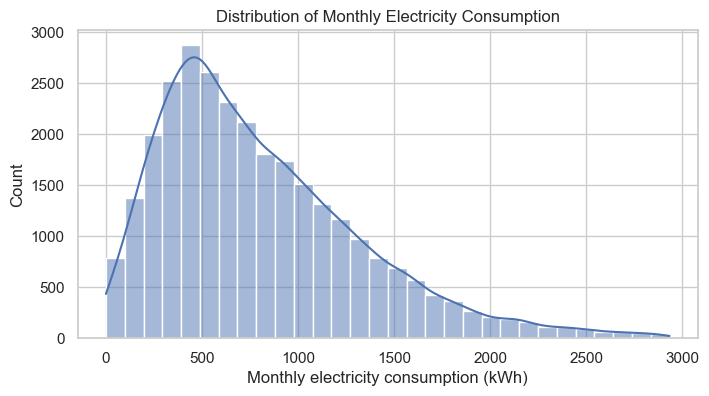

In [12]:
plt.figure(figsize=(8, 4))
sns.histplot(model_data["kWh_received_Total"], bins=30, kde=True)
plt.title("Distribution of Monthly Electricity Consumption")
plt.xlabel("Monthly electricity consumption (kWh)")
plt.ylabel("Count")
plt.show()

**Interpretation:**  
The target distribution is right-skewed, which means most households have moderate monthly consumption while a smaller number of households consume substantially more.

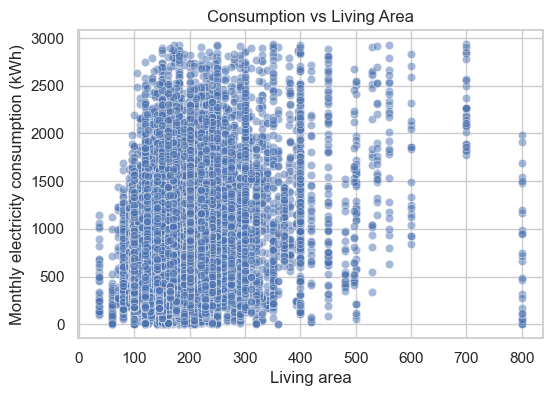

In [13]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=model_data, x="Building_LivingArea", y="kWh_received_Total", alpha=0.5)
plt.title("Consumption vs Living Area")
plt.xlabel("Living area")
plt.ylabel("Monthly electricity consumption (kWh)")
plt.show()

In [14]:
final_rows = model_data.shape[0]   # if pandas
print("Final rows:", final_rows)

Final rows: 29254


**Interpretation:**  
The relationship between living area and electricity consumption is positive but noisy. Larger homes tend to consume more electricity, but living area alone does not explain the full variation.

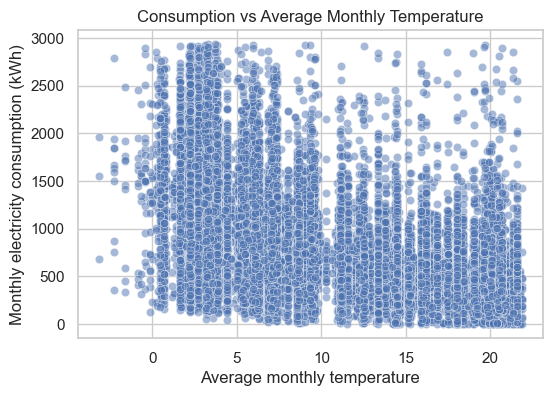

In [15]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=model_data, x="monthly_avg_temp", y="kWh_received_Total", alpha=0.5)
plt.title("Consumption vs Average Monthly Temperature")
plt.xlabel("Average monthly temperature")
plt.ylabel("Monthly electricity consumption (kWh)")
plt.show()

**Interpretation:**  
Lower outdoor temperature is generally associated with higher electricity consumption, which is consistent with stronger heating demand in colder periods.

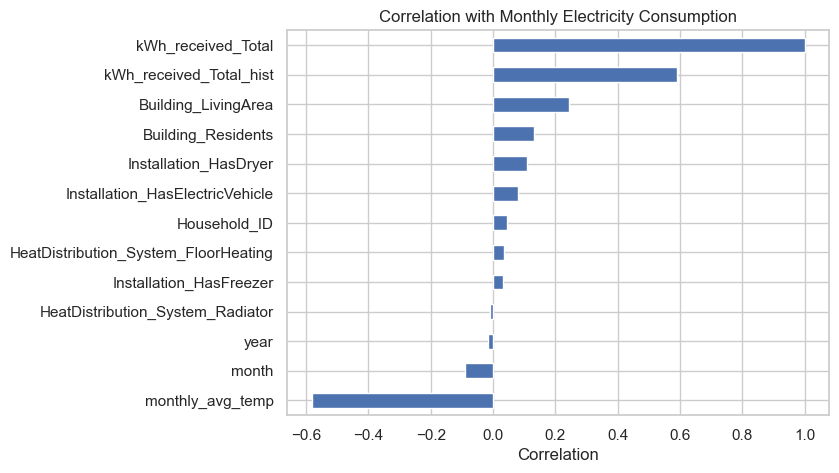

In [16]:
numeric_for_corr = model_data.select_dtypes(include=[np.number]).copy()

plt.figure(figsize=(7, 5))
corr_target = numeric_for_corr.corr(numeric_only=True)["kWh_received_Total"].sort_values()
corr_target.plot(kind="barh")
plt.title("Correlation with Monthly Electricity Consumption")
plt.xlabel("Correlation")
plt.show()

**Interpretation:**  
The correlation plot helps identify which numeric variables are most directly associated with the target. Correlation is only a first indicator and does not capture non-linear relationships.

## Time-Based Train/Test Split

I split the data chronologically instead of randomly.
This is more realistic because the model is trained on earlier periods and evaluated on later periods.

In [17]:
unique_periods = np.array(sorted(model_data["period"].dropna().unique()))
split_idx = int(len(unique_periods) * 0.8)

train_periods = unique_periods[:split_idx]
test_periods = unique_periods[split_idx:]

train_data = model_data[model_data["period"].isin(train_periods)].copy()
test_data = model_data[model_data["period"].isin(test_periods)].copy()

print("Train periods:", train_periods[0], "to", train_periods[-1])
print("Test periods :", test_periods[0], "to", test_periods[-1])
print("Train rows:", len(train_data))
print("Test rows :", len(test_data))

Train periods: 2018-12-01 00:00:00 to 2023-01-01 00:00:00
Test periods : 2023-02-01 00:00:00 to 2024-02-01 00:00:00
Train rows: 18140
Test rows : 11114


## Feature Sets and Preprocessing Pipeline

I keep regression as the main task.

The preprocessing uses:
- median imputation for numeric variables
- most-frequent imputation for categorical variables
- one-hot encoding for categorical variables
- scaling for linear models

In [18]:
target_col = "kWh_received_Total"

drop_columns = ["Household_ID", "Timestamp", "period", target_col]
feature_data = model_data.drop(columns=[c for c in drop_columns if c in model_data.columns]).copy()

categorical_features = feature_data.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_features = [c for c in feature_data.columns if c not in categorical_features]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train = train_data.drop(columns=[c for c in drop_columns if c in train_data.columns]).copy()
y_train = train_data[target_col].copy()

X_test = test_data.drop(columns=[c for c in drop_columns if c in test_data.columns]).copy()
y_test = test_data[target_col].copy()

Numeric features: ['year', 'month', 'kWh_received_Total_hist', 'Building_Residents', 'Building_LivingArea', 'HeatDistribution_System_FloorHeating', 'HeatDistribution_System_Radiator', 'Installation_HasElectricVehicle', 'Installation_HasFreezer', 'Installation_HasDryer', 'monthly_avg_temp']
Categorical features: ['HeatPump_Installation_Type', 'season']


In [19]:
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_unscaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_unscaled, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## Baseline Regression Model

In [20]:
baseline_reg = DummyRegressor(strategy="mean")
baseline_reg.fit(X_train, y_train)
baseline_pred = baseline_reg.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline Regression Results")
print("MAE :", round(baseline_mae, 3))
print("RMSE:", round(baseline_rmse, 3))
print("R²  :", round(baseline_r2, 3))

Baseline Regression Results
MAE : 413.194
RMSE: 509.849
R²  : -0.017


## Linear Regression

In [21]:
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, linear_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, linear_pred))
r2_lr = r2_score(y_test, linear_pred)

print("Linear Regression Results")
print("MAE :", round(mae_lr, 3))
print("RMSE:", round(rmse_lr, 3))
print("R²  :", round(r2_lr, 3))

Linear Regression Results
MAE : 198.701
RMSE: 270.202
R²  : 0.714


## Random Forest with Small Hyperparameter Tuning

In [22]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_unscaled),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [1, 3]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
best_rf_model = rf_grid.best_estimator_
rf_pred = best_rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf = r2_score(y_test, rf_pred)

print("Best RF parameters:", rf_grid.best_params_)
print("Random Forest Results")
print("MAE :", round(mae_rf, 3))
print("RMSE:", round(rmse_rf, 3))
print("R²  :", round(r2_rf, 3))

Best RF parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}
Random Forest Results
MAE : 183.06
RMSE: 252.324
R²  : 0.751


In [23]:
regression_results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "MAE": [baseline_mae, mae_lr, mae_rf],
    "RMSE": [baseline_rmse, rmse_lr, rmse_rf],
    "R²": [baseline_r2, r2_lr, r2_rf]
}).round(3).sort_values(by="RMSE")

regression_results

,Model,MAE,RMSE,R²
2,Random Forest,183.060,252.324,0.751
1,Linear Regression,198.701,270.202,0.714
0,Baseline,413.194,509.849,-0.017


**Interpretation:**  
The baseline gives a reference point, the linear model tests a simple linear relationship, and the Random Forest captures more complex non-linear patterns. I expect the Random Forest to perform best if the relationship between household characteristics, weather, and consumption is not purely linear.

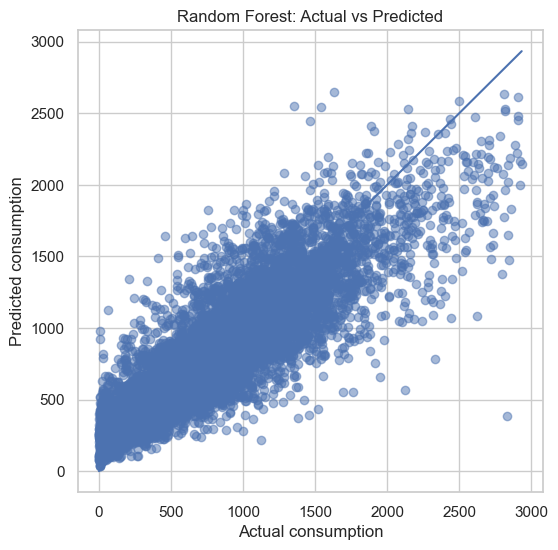

In [24]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual consumption")
plt.ylabel("Predicted consumption")
plt.show()

**Interpretation:**  
The closer the points are to the diagonal line, the better the model prediction. Large deviations indicate households or periods where the model does not capture the consumption pattern well.

## Classification as a Secondary Task

To complement the regression analysis, I also create a 3-class target based on consumption quantiles:
- low
- medium
- high

This is a secondary experiment because electricity consumption is fundamentally a continuous target.

In [25]:
classification_data = model_data.copy()
classification_data["consumption_class"] = pd.qcut(
    classification_data[target_col],
    q=3,
    labels=[0, 1, 2]
)

train_cls = classification_data[classification_data["period"].isin(train_periods)].copy()
test_cls = classification_data[classification_data["period"].isin(test_periods)].copy()

X_train_cls = train_cls.drop(columns=[c for c in drop_columns + ["consumption_class"] if c in train_cls.columns]).copy()
y_train_cls = train_cls["consumption_class"].copy()

X_test_cls = test_cls.drop(columns=[c for c in drop_columns + ["consumption_class"] if c in test_cls.columns]).copy()
y_test_cls = test_cls["consumption_class"].copy()

In [26]:
baseline_cls = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline_cls.fit(X_train_cls, y_train_cls)
baseline_cls_pred = baseline_cls.predict(X_test_cls)

baseline_cls_results = {
    "Accuracy": accuracy_score(y_test_cls, baseline_cls_pred),
    "Precision": precision_score(y_test_cls, baseline_cls_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test_cls, baseline_cls_pred, average="weighted", zero_division=0),
    "F1": f1_score(y_test_cls, baseline_cls_pred, average="weighted", zero_division=0),
}

pd.DataFrame([baseline_cls_results], index=["Baseline Classifier"]).round(3)

,Accuracy,Precision,Recall,F1
Baseline Classifier,0.314,0.099,0.314,0.15


In [27]:
log_reg_cls = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("model", LogisticRegression(max_iter=2000))
])

log_reg_cls.fit(X_train_cls, y_train_cls)
y_pred_cls = log_reg_cls.predict(X_test_cls)

classification_results = pd.DataFrame([{
    "Accuracy": accuracy_score(y_test_cls, y_pred_cls),
    "Precision": precision_score(y_test_cls, y_pred_cls, average="weighted", zero_division=0),
    "Recall": recall_score(y_test_cls, y_pred_cls, average="weighted", zero_division=0),
    "F1": f1_score(y_test_cls, y_pred_cls, average="weighted", zero_division=0),
}], index=["Logistic Regression"]).round(3)

classification_results

,Accuracy,Precision,Recall,F1
Logistic Regression,0.741,0.746,0.741,0.742


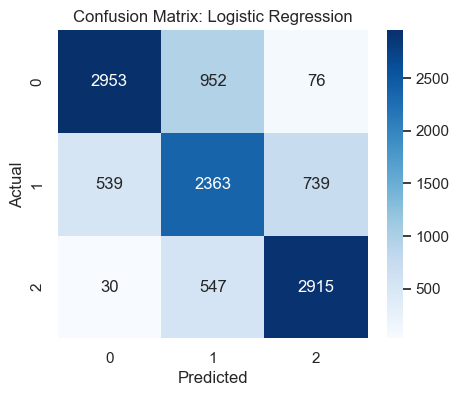

In [28]:
cm = confusion_matrix(y_test_cls, y_pred_cls)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix: Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Interpretation:**  
The confusion matrix shows which classes are easier or harder to identify. If the middle class is often confused with the low or high class, this suggests that a classification formulation may be less natural than regression for this problem.

## Summary Tables

In [29]:
all_results = pd.concat(
    [
        regression_results.set_index("Model"),
        classification_results.rename(index={"Logistic Regression": "Logistic Regression (classification)"})
    ],
    axis=0,
    sort=False
)

all_results

,MAE,RMSE,R²,Accuracy,Precision,Recall,F1
Random Forest,183.060,252.324,0.751,NaN,NaN,NaN,NaN
Linear Regression,198.701,270.202,0.714,NaN,NaN,NaN,NaN
Baseline,413.194,509.849,-0.017,NaN,NaN,NaN,NaN
Logistic Regression (classification),NaN,NaN,NaN,0.741,0.746,0.741,0.742


## Final Conclusion

### Main findings

- The **Random Forest** is the strongest regression candidate because it can capture non-linear relationships.
- The classification experiment is useful, but the problem remains better suited to **regression**.

### Limitations

- Electricity consumption is influenced by many factors that may not be fully observed in the dataset.
- Aggregating to monthly level simplifies the problem, but it can also hide short-term patterns.
- Even with improved preprocessing, prediction quality may still be limited by unobserved household behavior.

